2.1 Exercise - 1:



In [8]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

1. Read and display the image.

• Read the image using the Pillow library and display it.

• You can also use matplotlib to display the image.





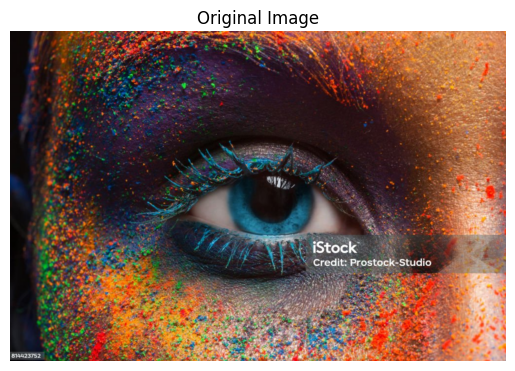

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open("/content/drive/MyDrive/AI ML/Data/eye.png")

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [10]:
img_array = np.array(image)

print("Image Shape:", img_array.shape)

Image Shape: (836, 1258, 4)


2. Display only the top left corner of 100x100 pixels.

• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing.


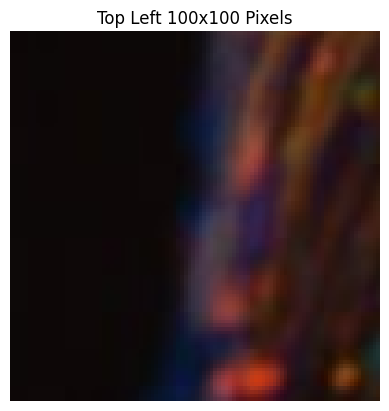

In [11]:
top_left = img_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

3. Show the three color channels (R, G, B).

• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}

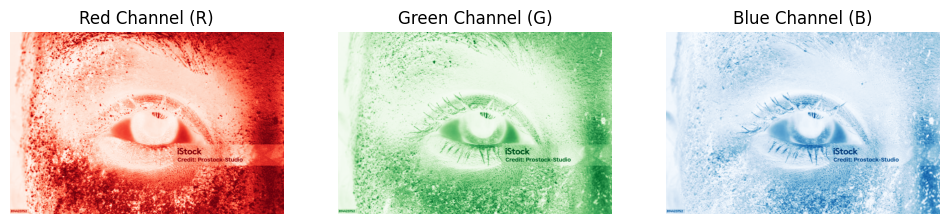

In [12]:
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel (R)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel (G)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel (B)")
plt.axis("off")

plt.show()

4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:

• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image.

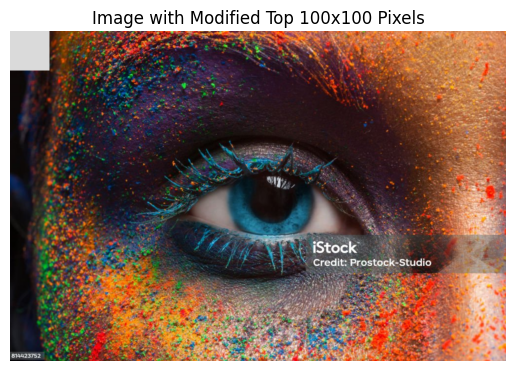

In [13]:
modified_img = img_array.copy()

modified_img[0:100, 0:100] = 210

plt.imshow(modified_img)
plt.title("Image with Modified Top 100x100 Pixels")
plt.axis("off")
plt.show()

2.2 Exercise - 2:

Complete all the Task.

1. Load and display a grayscale image.

• Load a grayscale image using the Pillow library.

• Display the grayscale image using matplotlib.

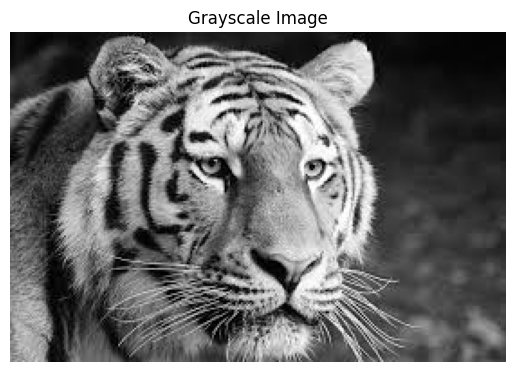

In [14]:
image = Image.open("/content/drive/MyDrive/AI ML/Data/tiger.jpeg").convert("L")

plt.imshow(image, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [15]:
img_array = np.array(image)

print("Image shape:", img_array.shape)

Image shape: (183, 275)


2. Extract and display the middle section of the image (150 pixels).

• Extract a 150 pixel section from the center of the image using NumPy array slicing.

• Display this cropped image using matplotlib.

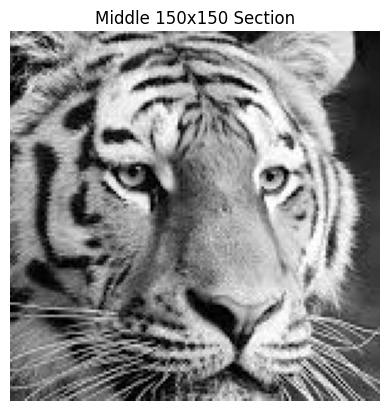

In [16]:
h, w = img_array.shape

center_h = h // 2
center_w = w // 2

middle_section = img_array[center_h-75:center_h+75, center_w-75:center_w+75]

plt.imshow(middle_section, cmap='gray')
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).

• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).

• Display the resulting binary image.

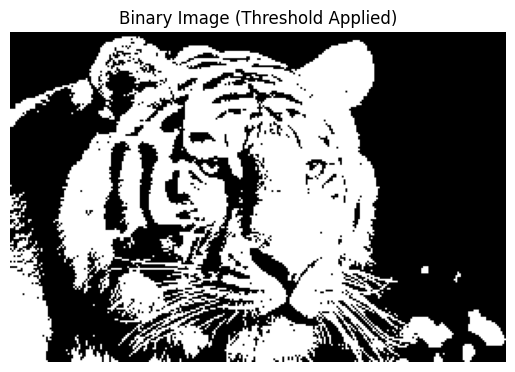

In [17]:
binary_img = img_array.copy()

binary_img[binary_img < 100] = 0
binary_img[binary_img >= 100] = 255

plt.imshow(binary_img, cmap='gray')
plt.title("Binary Image (Threshold Applied)")
plt.axis("off")
plt.show()

4. Rotate the image 90 degrees clockwise and display the result.

• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating
the image array.

• Display the rotated image using matplotlib.

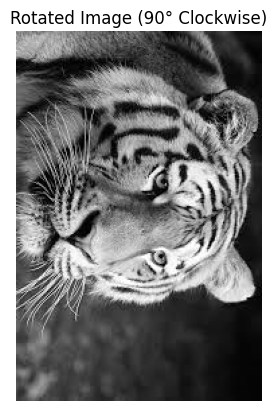

In [18]:
rotated_img = np.rot90(img_array, k=-1)

plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated Image (90° Clockwise)")
plt.axis("off")
plt.show()

5. Convert the grayscale image to an RGB image.

• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).

• Display the converted RGB image using matplotlib.

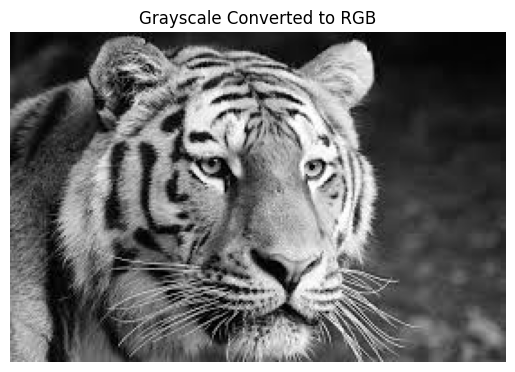

In [19]:
rgb_img = np.stack((img_array,)*3, axis=-1)

plt.imshow(rgb_img)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

3 Image Compression and Decompression using PCA.

In this exercise, build a PCA from scratch using explained variance method for image compression task.
You are expected to compute the necessary matrices from the scratch. Dataset: Use image of your
choice.

1. Load and Prepare Data:

• Fetch an image of you choice.{If colour convert to grayscale}

• Center the dataset - Standaridze the Data.

• Calculate the covaraince matrix of the Standaridze data.

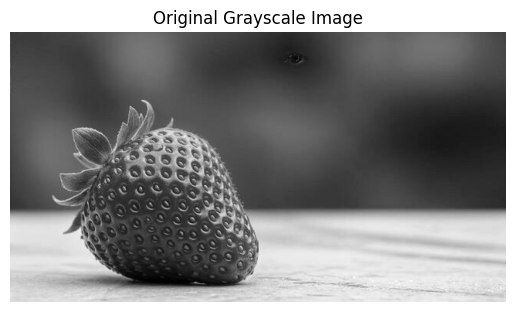

Image Shape: (350, 642)


In [20]:
img = Image.open("/content/drive/MyDrive/AI ML/Data/img.jpg")

img = img.convert("L")

img_array = np.array(img, dtype=np.float64)

plt.imshow(img_array, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

print("Image Shape:", img_array.shape)

In [23]:
mean = np.mean(img_array, axis=0)

X_centered = img_array - mean

print("Data centered successfully")

Data centered successfully


In [24]:
cov_matrix = np.cov(X_centered, rowvar=False)

print("Covariance Matrix Shape:", cov_matrix.shape)

Covariance Matrix Shape: (642, 642)


2. Eigen Decomposition and Identifying Principal Components:

• Compute Eigen Values and Eigen Vectors.

• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to
the highest eigenvalues.

• Identify the Principal Components with the help of cumulative Sum plot.

In [35]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)

Eigenvalues shape: (642,)
Eigenvectors shape: (642, 642)


In [36]:
sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

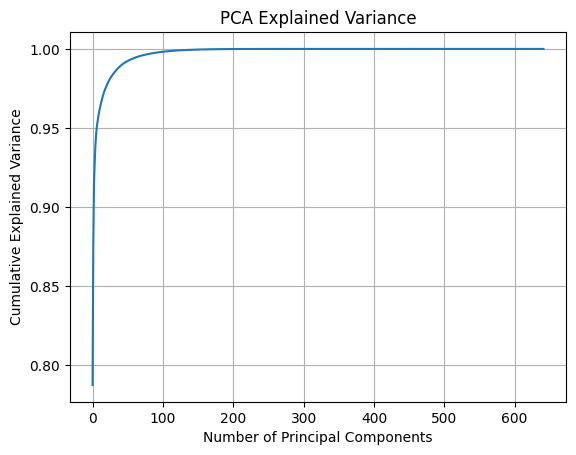

In [37]:
explained_variance = eigenvalues / np.sum(eigenvalues)

cumulative_variance = np.cumsum(explained_variance)

plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

3. Reconstruction and Experiment:

• Reconstruction: Transform the original data by multiplying it with the selected eigenvec-
tors(PCs) to obtain a lower-dimensional representation.

• Experiments: Pick Four different combination of principal components with various ex-
plained variance value and compare the result.

• Display the Results and Evaluate.

In [38]:
def reconstruct_image(k):

    pcs = eigenvectors[:, :k]

    compressed = np.dot(X_centered, pcs)

    reconstructed = np.dot(compressed, pcs.T) + mean

    reconstructed = np.real(reconstructed)

    reconstructed = np.clip(reconstructed, 0, 255)

    return reconstructed

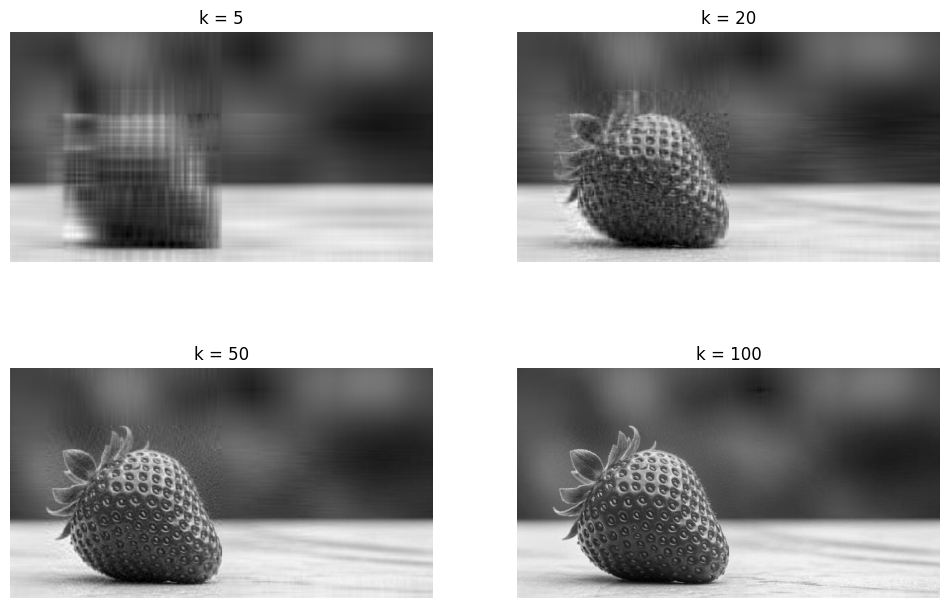

In [39]:
k_values = [5, 20, 50, 100]

plt.figure(figsize=(12,8))

for i, k in enumerate(k_values):

    reconstructed_img = reconstruct_image(k)

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed_img, cmap='gray')
    plt.title(f"k = {k}")
    plt.axis("off")

plt.show()

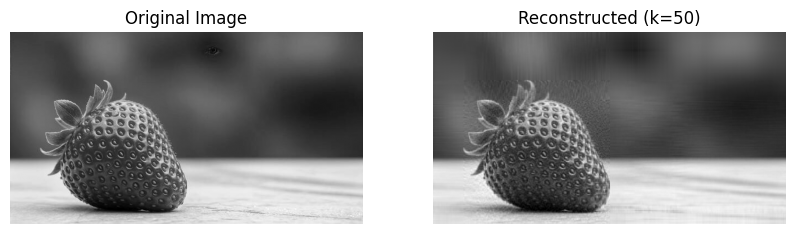

In [40]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_array, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(reconstruct_image(50), cmap='gray')
plt.title("Reconstructed (k=50)")
plt.axis("off")

plt.show()